# Notebook 4: Linear Probing
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Lineare Probes trainieren, um zu testen, welche Information in welcher Schicht kodiert ist.

> **Aufgabe:** Implementiere die Zellen schrittweise. Hilfreiche Dokumentation:
> - PyTorch Hooks: https://pytorch.org/docs/stable/generated/torch.nn.Module.register_forward_hook.html
> - Scikit-Learn LogisticRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
> - Scikit-Learn cross_val_score: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
> - MLflow: https://mlflow.org/docs/latest/python_api/mlflow.html

## Hintergrund: Was ist lineares Probing?

**Probing** testet, ob bestimmte Information in den Aktivierungen einer Schicht **linear dekodierbar** ist.

**Vorgehen:**
1. Erstelle Datensatz mit Labels (korrekte vs. falsche Hauptstadt)
2. Extrahiere Hidden States jeder Schicht mit **Forward Hooks**
3. Trainiere **LogisticRegression** (Probe) pro Schicht
4. Plotte Genauigkeit pro Schicht → "Informationsbildungskurve"

**Warum Forward Hooks?**
Forward Hooks sind PyTorch-Callbacks, die nach jedem Forward Pass durch ein Modul aufgerufen werden. So können wir Aktivierungen "abgreifen", ohne das Modell zu verändern.

```python
def hook_fn(module, input, output):
    # output[0] enthält die Hidden States dieser Schicht
    aktivierungen[layer_idx] = output[0].detach().cpu()

layer.register_forward_hook(hook_fn)
```

**Warum linear?** Ein linearer Probe ist zu schwach, um selbst komplexe Muster zu lernen — wenn er trotzdem gut funktioniert, liegt es am Modell.

## 1. Setup

In [1]:
# TODO: Importiere torch, numpy, matplotlib
# TODO: Importiere LogisticRegression und cross_val_score aus sklearn
# TODO: Importiere StandardScaler aus sklearn.preprocessing
# TODO: Lade Tokenizer und Modell (wie in Notebook 1)
#
# Optional: Versuche mlflow zu importieren (try/except)
# MLflow-Dokumentation: https://mlflow.org/docs/latest/python_api/mlflow.html
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import torch
import os
import numpy as np
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [2]:
MODEL_NAME = "EleutherAI/pythia-410m"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tokenizer laden
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Modell laden
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",   # wichtig für Attention-Ausgabe
    torch_dtype=torch.float32
)

# Auf Gerät verschieben
model = model.to(device)

# Eval-Modus
model.eval()

print("Modell geladen!")
print("Device:", device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Modell geladen!
Device: cuda


## 2. Datensatz erstellen

In [3]:
# TODO: Erstelle einen Datensatz mit mindestens 20 Länder-Hauptstadt-Paaren.
# Für jedes Paar erstelle TWO Prompts:
#   Label 1 (korrekt): "The capital of <Country> is <CorrectCapital>"
#   Label 0 (falsch):  "The capital of <Country> is <WrongCapital>"
#
# Beispiel-Struktur:
# COUNTRY_CAPITAL_PAIRS = [
#     ("France", "Paris", "Madrid"),
#     ("Germany", "Berlin", "Vienna"),
#     ...
# ]
#
# Hinweis: Du brauchst mindestens 20 Paare = 40 Beispiele für sinnvolle Kreuzvalidierung
# Hinweis: Die "falsche" Hauptstadt sollte eine echte Hauptstadt sein (kein Nonsense)
#
# Ausgabe: all_prompts (Liste aller Prompts), labels (np.array mit 0/1)

import numpy as np
all_prompts = []
labels = []
'''
# (Thema, positives Adjektiv, negatives Adjektiv)
SENTIMENT_PAIRS = [
    ("movie", "great", "terrible"),
    ("food", "delicious", "awful"),
    ("service", "excellent", "horrible"),
    ("hotel", "wonderful", "disgusting"),
    ("product", "amazing", "useless"),
    ("book", "interesting", "boring"),
    ("game", "fun", "annoying"),
    ("experience", "pleasant", "frustrating"),
    ("staff", "friendly", "rude"),
    ("quality", "outstanding", "poor"),
    ("design", "beautiful", "ugly"),
    ("performance", "impressive", "disappointing"),
    ("meeting", "productive", "pointless"),
    ("weather", "beautiful", "miserable"),
    ("room", "clean", "dirty"),
    ("delivery", "fast", "late"),
    ("interface", "simple", "confusing"),
    ("explanation", "clear", "unclear"),
    ("result", "successful", "failed"),
    ("app", "useful", "broken"),
]



for topic, positive_word, negative_word in SENTIMENT_PAIRS:
    # Label 1: positiv
    all_prompts.append(f"The {topic} was {positive_word}.")
    labels.append(1)

    # Label 0: negativ
    all_prompts.append(f"The {topic} was {negative_word}.")
    labels.append(0)

labels = np.array(labels)

print("Anzahl Prompts:", len(all_prompts))
print("Labels shape:", labels.shape)

for prompt, label in zip(all_prompts[:10], labels[:10]):
    print(label, "→", prompt)
'''

########################################

'''
SENTIMENT_PAIRS = [
    ("great",       "positive", "negative"),
    ("excellent",   "positive", "negative"),
    ("amazing",     "positive", "negative"),
    ("wonderful",   "positive", "negative"),
    ("fantastic",   "positive", "negative"),
    ("delicious",   "positive", "negative"),
    ("pleasant",    "positive", "negative"),
    ("beautiful",   "positive", "negative"),
    ("friendly",    "positive", "negative"),
    ("successful",  "positive", "negative"),
    ("terrible",    "negative", "positive"),
    ("awful",       "negative", "positive"),
    ("horrible",    "negative", "positive"),
    ("disgusting",  "negative", "positive"),
    ("boring",      "negative", "positive"),
    ("annoying",    "negative", "positive"),
    ("frustrating", "negative", "positive"),
    ("rude",        "negative", "positive"),
    ("ugly",        "negative", "positive"),
    ("miserable",   "negative", "positive"),
]
'''
###################################
SENTIMENT_PAIRS = [

    # Positive
    ("great",        "positive", "negative"),
    ("excellent",    "positive", "neutral"),
    ("amazing",      "positive", "negative"),
    ("wonderful",    "positive", "neutral"),
    ("fantastic",    "positive", "negative"),
    ("delicious",    "positive", "neutral"),
    ("pleasant",     "positive", "negative"),
    ("beautiful",    "positive", "neutral"),
    ("friendly",     "positive", "negative"),
    ("successful",   "positive", "neutral"),
    ("helpful",      "positive", "negative"),
    ("brilliant",    "positive", "neutral"),
    ("outstanding",  "positive", "negative"),
    ("perfect",      "positive", "neutral"),

    # Negative
    ("terrible",     "negative", "positive"),
    ("awful",        "negative", "neutral"),
    ("horrible",     "negative", "positive"),
    ("disgusting",   "negative", "neutral"),
    ("boring",       "negative", "positive"),
    ("annoying",     "negative", "neutral"),
    ("frustrating",  "negative", "positive"),
    ("rude",         "negative", "neutral"),
    ("ugly",         "negative", "positive"),
    ("miserable",    "negative", "neutral"),
    ("useless",      "negative", "positive"),
    ("disappointing","negative", "neutral"),
    ("broken",       "negative", "positive"),

    # Neutral
    ("table",        "neutral", "positive"),
    ("chair",        "neutral", "negative"),
    ("window",       "neutral", "positive"),
    ("computer",     "neutral", "negative"),
    ("book",         "neutral", "positive"),
    ("phone",        "neutral", "negative"),
    ("paper",        "neutral", "positive"),
    ("building",     "neutral", "negative"),
    ("street",       "neutral", "positive"),
    ("car",          "neutral", "negative"),
    ("keyboard",     "neutral", "positive"),
    ("monitor",      "neutral", "negative"),
    ("bottle",       "neutral", "positive"),
]


for word, correct_sentiment, wrong_sentiment in SENTIMENT_PAIRS:

    # korrekt
    all_prompts.append(
        f"The sentiment of '{word}' is {correct_sentiment}."
    )
    labels.append(1)

    # falsch
    all_prompts.append(
        f"The sentiment of '{word}' is {wrong_sentiment}."
    )
    labels.append(0)

labels = np.array(labels)

for prompt, label in zip(all_prompts[:10], labels[:10]):
    print(label, "→", prompt)

1 → The sentiment of 'great' is positive.
0 → The sentiment of 'great' is negative.
1 → The sentiment of 'excellent' is positive.
0 → The sentiment of 'excellent' is neutral.
1 → The sentiment of 'amazing' is positive.
0 → The sentiment of 'amazing' is negative.
1 → The sentiment of 'wonderful' is positive.
0 → The sentiment of 'wonderful' is neutral.
1 → The sentiment of 'fantastic' is positive.
0 → The sentiment of 'fantastic' is negative.


## 3. Aktivierungen mit Forward Hooks extrahieren

In [4]:
#for i, layer in enumerate(model.gpt_neox.layers):
#    print(i,"  ", layer)

In [5]:
# TODO: Implementiere extract_all_layer_activations(prompts, batch_size=4):
#
# Schritt 1: Registriere einen Forward Hook auf JEDER Schicht:
#   for i, layer in enumerate(model.gpt_neox.layers):
#       hooks.append(layer.register_forward_hook(make_hook(i)))
#
# Schritt 2: Führe einen Forward Pass durch und sammle die Aktivierungen.
#   WICHTIG: Nutze output[0] (der erste Eintrag des Outputs ist der Hidden State)
#
# Schritt 3: Entferne alle Hooks nach dem Forward Pass:
#   for h in hooks: h.remove()
#
# Schritt 4: Extrahiere den Hidden State am LETZTEN gültigen Token:
#   - Nutze attention_mask um den letzten nicht-Padding-Token zu finden
#   - last_valid = attention_mask[sample_idx].sum().item() - 1
#
# Dokumentation zu register_forward_hook:
#   https://pytorch.org/docs/stable/generated/torch.nn.Module.register_forward_hook.html
#
# WICHTIG: Verwende torch.no_grad() für alle Forward Passes\!
def extract_all_layer_activations(prompts, batch_size=4):
    all_activations = []
    n_layers = model.config.num_hidden_layers

    for start in range(0, len(prompts), batch_size):
        batch_prompts = prompts[start:start + batch_size]
        #print(batch_prompts)
        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        attention_mask = inputs["attention_mask"]
        #print(inputs) 
        '''
        tokens = [tokenizer.decode([t]) for t in inputs["input_ids"][1]]
        print("Tokens:")
        for i, tok in enumerate(tokens):
            print(i, repr(tok))
        '''
        
        layer_cache = {}
        hooks = []

        def make_hook(layer_idx):
            def hook_fn(module, input, output):
                layer_cache[layer_idx] =output.detach().clone()
                return output

            return hook_fn

        for i, layer in enumerate(model.gpt_neox.layers):
            hooks.append(layer.register_forward_hook(make_hook(i)))
        try:
            with torch.no_grad():
                test = model(**inputs)
        finally:
            for h in hooks:
                h.remove()

        batch_acts = []
        #print(layer_cache[0].shape)
        for sample_idx in range(len(batch_prompts)):
            last_valid = attention_mask[sample_idx].sum().item() - 1

            sample_layers = []

            for layer_idx in range(n_layers):
                vec = layer_cache[layer_idx][sample_idx, last_valid, :]
                sample_layers.append(vec.cpu().numpy())

            sample_layers = np.stack(sample_layers)
            batch_acts.append(sample_layers)

        batch_acts = np.stack(batch_acts)
        all_activations.append(batch_acts)

    return np.concatenate(all_activations, axis=0)


In [6]:
X = extract_all_layer_activations(all_prompts, batch_size=4)

print(X.shape)
print(labels.shape)
#print(X)

(80, 24, 1024)
(80,)


## 4. Lineare Probes trainieren

In [7]:
# TODO: Implementiere train_probe_per_layer(activations, labels, n_layers):
#
# Für JEDE Schicht:
#   1. X = activations[layer_idx]   # Shape: (n_samples, hidden_size)
#   2. Standardisiere X mit StandardScaler (wichtig für Logistische Regression\!)
#      scaler = StandardScaler()
#      X_scaled = scaler.fit_transform(X)
#   3. Erstelle LogisticRegression(max_iter=1000, C=1.0)
#   4. Berechne 5-fache Kreuzvalidierung:
#      cv_scores = cross_val_score(probe, X_scaled, y, cv=5, scoring="accuracy")
#   5. Speichere Mittelwert und Standardabweichung
#
# Rückgabe: accuracies (n_layers,), std_devs (n_layers,)
#
# Tipp: StandardScaler-Dokumentation:
#   https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

def train_probe_per_layer(activations, labels, n_layers):
    accuracies = np.zeros(n_layers)
    std_devs = np.zeros(n_layers)

    y = labels

    for layer_idx in range(n_layers):
        # activations shape: [n_samples, n_layers, hidden_size]
        X = activations[:, layer_idx, :]   # [n_samples, hidden_size]

        # Standardisierung
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Probe
        probe = LogisticRegression(
            max_iter=1000,
            C=1.0,
        )

        # 5-fold Cross Validation
        cv_scores = cross_val_score(
            probe,
            X_scaled,
            y,
            cv=5,
            scoring="accuracy"
        )

        accuracies[layer_idx] = cv_scores.mean()
        std_devs[layer_idx] = cv_scores.std()

        print(
            f"Layer {layer_idx:02d}: "
            f"Accuracy = {accuracies[layer_idx]:.3f} "
            f"+/- {std_devs[layer_idx]:.3f}"
        )

    return accuracies, std_devs

In [8]:
#X[:, 1, :] 

In [9]:
n_layers = model.config.num_hidden_layers

accuracies, std_devs = train_probe_per_layer(
    X,
    labels,
    n_layers
)

print(accuracies.shape)
print(std_devs.shape)

Layer 00: Accuracy = 0.487 +/- 0.047
Layer 01: Accuracy = 0.537 +/- 0.085
Layer 02: Accuracy = 0.537 +/- 0.208
Layer 03: Accuracy = 0.588 +/- 0.064
Layer 04: Accuracy = 0.662 +/- 0.075
Layer 05: Accuracy = 0.600 +/- 0.151
Layer 06: Accuracy = 0.675 +/- 0.155
Layer 07: Accuracy = 0.787 +/- 0.102
Layer 08: Accuracy = 0.800 +/- 0.127
Layer 09: Accuracy = 0.800 +/- 0.061
Layer 10: Accuracy = 0.850 +/- 0.064
Layer 11: Accuracy = 0.887 +/- 0.025
Layer 12: Accuracy = 0.887 +/- 0.047
Layer 13: Accuracy = 0.863 +/- 0.047
Layer 14: Accuracy = 0.838 +/- 0.050
Layer 15: Accuracy = 0.850 +/- 0.094
Layer 16: Accuracy = 0.787 +/- 0.085
Layer 17: Accuracy = 0.762 +/- 0.100
Layer 18: Accuracy = 0.713 +/- 0.116
Layer 19: Accuracy = 0.750 +/- 0.131
Layer 20: Accuracy = 0.713 +/- 0.122
Layer 21: Accuracy = 0.738 +/- 0.121
Layer 22: Accuracy = 0.700 +/- 0.115
Layer 23: Accuracy = 0.688 +/- 0.079
(24,)
(24,)


## 5. Informationsbildungskurve plotten

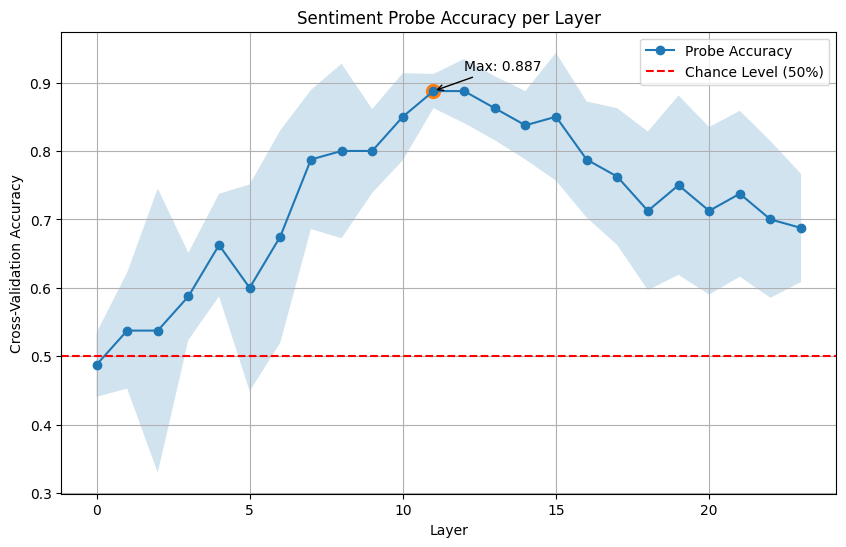

Best Layer: 11
Best Accuracy: 0.8875
Std Dev: 0.0250


In [10]:
# TODO: Erstelle einen Linienchart mit plt.plot():
#   - X-Achse: Schicht-Index
#   - Y-Achse: CV-Genauigkeit
#   - Fehlerband: plt.fill_between(..., acc - std, acc + std, alpha=0.2)
#   - Horizontale Linie bei 0.5 (Chance-Level): plt.axhline(y=0.5, ...)
#
# TODO: Annotiere die Schicht mit der besten Genauigkeit:
#   best_layer = int(accuracies.argmax())
#   plt.annotate(f"Max: {accuracies[best_layer]:.3f}", ...)
#
# Frage: In welcher Schicht bildet sich das Wissen über die Hauptstadt heraus?
#
# Dokumentation plt.fill_between:
#   https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html



layers = np.arange(len(accuracies))

best_layer = int(np.argmax(accuracies))

plt.figure(figsize=(10, 6))

# Genauigkeit
plt.plot(
    layers,
    accuracies,
    marker="o",
    label="Probe Accuracy"
)

# Fehlerband
plt.fill_between(
    layers,
    accuracies - std_devs,
    accuracies + std_devs,
    alpha=0.2
)

# Chance-Level
plt.axhline(
    y=0.5,
    linestyle="--",
    color="red",
    label="Chance Level (50%)"
)

# Beste Schicht markieren
plt.scatter(
    best_layer,
    accuracies[best_layer],
    s=100
)

plt.annotate(
    f"Max: {accuracies[best_layer]:.3f}",
    xy=(best_layer, accuracies[best_layer]),
    xytext=(best_layer + 1, accuracies[best_layer] + 0.03),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Layer")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Sentiment Probe Accuracy per Layer")
plt.legend()
plt.grid(True)

plt.show()

print(f"Best Layer: {best_layer}")
print(f"Best Accuracy: {accuracies[best_layer]:.4f}")
print(f"Std Dev: {std_devs[best_layer]:.4f}")

## 6. MLflow Experiment-Tracking

In [15]:
# TODO: Falls MLflow verfügbar, logge das Experiment:
#
# mlflow.set_experiment("linear_probing_pythia410m")
# with mlflow.start_run(run_name="capital_city_probe"):
#     mlflow.log_param("model", MODEL_NAME)
#     mlflow.log_param("n_examples", len(all_prompts))
#     for layer_idx, acc in enumerate(accuracies):
#         mlflow.log_metric(f"layer_{layer_idx:02d}_accuracy", acc, step=layer_idx)
#     mlflow.log_metric("best_accuracy", accuracies.max())
#     mlflow.log_metric("best_layer", int(accuracies.argmax()))
#
# WICHTIG: Falls MLflow nicht installiert ist, gib die Ergebnisse als print()-Tabelle aus.
#
# MLflow-Dokumentation: https://mlflow.org/docs/latest/python_api/mlflow.html
import os
try:
    import mlflow
    import mlflow.pytorch
    mlflow.set_experiment("linear_probing_pythia410m")

    MLFLOW_AVAILABLE = True
except ImportError:
    print("MLflow nicht installiert — Überspringen Sie die MLflow-Aufgaben.")
    print("Installation: pip install mlflow")
    MLFLOW_AVAILABLE = False

    
mlflow.set_experiment("linear_probing_pythia410m")
with mlflow.start_run(run_name="Sentiment analyse"):
     mlflow.log_param("model", MODEL_NAME)
     mlflow.log_param("n_examples", len(all_prompts))
     for layer_idx, acc in enumerate(accuracies):
         mlflow.log_metric(f"layer_{layer_idx:02d}_accuracy", acc, step=layer_idx)
     mlflow.log_metric("best_accuracy", accuracies.max())
     mlflow.log_metric("best_layer", int(accuracies.argmax()))

In [16]:
print(mlflow.get_tracking_uri())

sqlite:///C:/master_ai/ai_framework/Notebooks_Block3/semester_projekct/notebooks/mlflow.db


## 7. Reflexionsfragen

In [12]:
# Beantworte folgende Fragen:
#
# 1. In welcher Schicht erreicht die Probe-Genauigkeit ihr Maximum?
# 2. Was bedeutet eine Genauigkeit von ~50%? Was bedeutet ~90%?
# 3. Was ist der Unterschied zwischen Probing und Activation Patching?
#    (Denke an: Korrelation vs. Kausalität)
# 4. Warum ist Standardisierung (StandardScaler) vor dem Probe-Training wichtig?
# 5. Was würde passieren, wenn du einen nicht-linearen Probe (z.B. MLP) verwendest?
#    Wäre das besser oder schlechter für Interpretierbarkeit? Warum?